# Binary appropriateness pipeline (clean)

Trains classifiers on `feature_df_plus` to predict **inappropriate** vs **appropriate** therapy (`mapped_letter`: I vs A). U has been merged into I.

**Optional installs** (if imports fail): `pip install imblearn shap`

**Run order:** top to bottom. After editing `model.py`, re-run the reload cell, then pipelines, then training/SHAP.

**Note:** If you change `num_cols` / `cat_cols` / `feature_df_plus`, re-run the pipeline-definition cell so sklearn steps see the new column lists.


In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import model as mm
import tools.helpers as hh

warnings.filterwarnings("ignore", category=UserWarning)


In [3]:
# Re-run after editing model.py
import importlib
importlib.reload(mm)


<module 'model' from '/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/model.py'>

In [4]:
pd.set_option("display.max_columns", None)

DATA_ROOT = Path("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building")
PARQ_DIR = DATA_ROOT / "parq"


## Load feature table

Point `FEATURE_PARQUET` at your built binary-target parquet under `parq/`.


In [13]:
# Built upstream (e.g. feature engineering notebook)
# FEATURE_PARQUET = PARQ_DIR / "feature_df_binary_target_30Mar26_1817.parquet"
FEATURE_PARQUET = PARQ_DIR / "feature_df_binary_target_13Apr26_0713.parquet"


feature_df = hh.load_data(str(FEATURE_PARQUET)).copy()


## Binary target

Collapse unknown **U** into inappropriate **I** so the task stays binary (A vs I).


In [14]:
# Positive label I = inappropriate; A = appropriate
feature_df["mapped_letter"] = feature_df["mapped_letter"].replace("U", "I")
print(feature_df["mapped_letter"].value_counts())


mapped_letter
A    2591
I     814
Name: count, dtype: int64


## Build `feature_df_plus`

Temporal vitals/labs are detected by suffix (`_max`, `_median`, …). `prior_ab_count` and `prior_resistance_count` are excluded from that auto-list so they are not duplicated.


In [15]:
temporal_suffixes = (
    "_max", "_median", "_min", "_count", "_delta", "_first_value",
    "_last_value", "_slope", "_std",
)
non_temporal = {"prior_ab_count", "prior_resistance_count", "charlson_comorbidity_index"}
vitals_lab_cols = sorted([
    c for c in feature_df.columns
    if any(c.endswith(s) for s in temporal_suffixes) and c not in non_temporal
])

feature_df_plus = feature_df[
    ["subject_id", "hadm_id"]
    + vitals_lab_cols
    + [
        "gender", "age_at_admission", "insurance", "race", "marital_status",
        "language", "admission_type", "admission_location",
    ]
    + ["prior_ab_count"]
    + [
        "ESBL_Enterobacterales_drug", "MDR_GNB_drug", "MRSA_drug",
        "Other_Gram_Positive_drug", "Pseudomonas_drug", "Standard_GNB_drug",
    ]
    + [
        "prior_resistance_count", "charlson_comorbidity_index",
        "hours_adm_to_ast", "hours_icu_to_ast",
    ]
    + ["final_class", "mapped_letter"]
]
print(f"Temporal vitals/lab columns: {len(vitals_lab_cols)}; feature_df_plus shape: {feature_df_plus.shape}")


Temporal vitals/lab columns: 369; feature_df_plus shape: (3882, 392)


## Column groups for `split_train_test` and pipelines


In [16]:
pid_cols = ["subject_id", "hadm_id"]
target_col = ["mapped_letter"]

num_cols = vitals_lab_cols + [
    "prior_ab_count",
    "age_at_admission",
    "charlson_comorbidity_index",
    "hours_adm_to_ast",
    "hours_icu_to_ast",
    "prior_resistance_count",
]

cat_cols = [
    "gender", "insurance", "race", "marital_status", "language",
    "admission_type", "admission_location",
    "ESBL_Enterobacterales_drug", "MDR_GNB_drug", "MRSA_drug",
    "Other_Gram_Positive_drug", "Pseudomonas_drug", "Standard_GNB_drug",
]

bacteria_cols = [
    "Acinetobacter", "AmpC_Producers",
    "Carbopenam Resistant Enterobacterales", "ESBL_Enterobacterales",
    "Enterococcus_VRE", "Enterococcus_VSE", "Low_Significance", "MRSA",
    "MSSA", "Non_ESBL_Enterobacterales", "Other_NonFermenters",
    "Pseudomonas", "Streptococcus_pneumoniae",
]

input_col = num_cols + cat_cols

print(
    f"num_cols={len(num_cols)}, cat_cols={len(cat_cols)}, "
    f"input_col={len(input_col)}, bacteria_cols={len(bacteria_cols)}"
)


num_cols=375, cat_cols=13, input_col=388, bacteria_cols=13


## Train / validation / test split (stratified)


In [17]:
X_train, X_val, X_test, y_train, y_val, y_test = mm.split_train_test(
    df=feature_df_plus,
    input_col=input_col,
    target_col=target_col,
    test_size=0.20,
    val_size=0.15,
    random_state=42,
)


Split sizes -- Train: 2522, Val: 583, Test: 777
Split ratios -- Train: 65%, Val: 15%, Test: 20%
Positive rate -- Train: 0.210, Val: 0.209, Test: 0.210


## Pipeline definitions

One pipeline object per algorithm; preprocessing is wired inside `mm.make_pipeline`.


In [18]:
pipe_rf = mm.make_pipeline(mm.classifier_rf(), cat_cols, num_cols)
pipe_xgb = mm.make_pipeline(mm.classifier_xgb(), cat_cols, num_cols)
pipe_lgb = mm.make_pipeline(mm.classifier_lgb(), cat_cols, num_cols)
pipe_cb = mm.make_pipeline(mm.classifier_cb(), cat_cols, num_cols)
pipe_et = mm.make_pipeline(mm.classifier_et(), cat_cols, num_cols)
pipe_dt = mm.make_pipeline(mm.classifier_dt(), cat_cols, num_cols)
pipe_ada = mm.make_pipeline(mm.classifier_ada(), cat_cols, num_cols)
pipe_gb = mm.make_pipeline(mm.classifier_gb(), cat_cols, num_cols)

pipe_lr = mm.make_pipeline(mm.classifier_lr(), cat_cols, num_cols)
# pipe_ridge = mm.make_pipeline(mm.classifier_ridge(), cat_cols, num_cols)
pipe_sgd = mm.make_pipeline(mm.classifier_sgd(), cat_cols, num_cols)

pipe_svm = mm.make_pipeline(mm.classifier_svm(), cat_cols, num_cols)
pipe_knn = mm.make_pipeline(mm.classifier_knn(), cat_cols, num_cols)
pipe_nb = mm.make_pipeline(mm.classifier_nb(), cat_cols, num_cols)
pipe_mlp = mm.make_pipeline(mm.classifier_mlp(), cat_cols, num_cols)


## Model registry

Comment out any estimators you do not want to train (full grid is slow).


In [19]:
pipes = {
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgb,
    "CatBoost": pipe_cb,
    "ExtraTrees": pipe_et,
    "DecisionTree": pipe_dt,
    "AdaBoost": pipe_ada,
    "GradientBoosting": pipe_gb,
    "LogisticRegression": pipe_lr,
    # "RidgeClassifier": pipe_ridge,
    "SGDClassifier": pipe_sgd,
    "SVM": pipe_svm,
    "KNN": pipe_knn,
    "NaiveBayes": pipe_nb,
    "MLP": pipe_mlp,
}


## Fit, optimize threshold on validation, evaluate on test

For each model: `fit` on train → threshold tuned on **val** (F1) → metrics and curves on **test** → `check_overfitting` on train vs val.



--- Optimizing Threshold on VALIDATION set for RandomForest (Metric: F1) ---
    Val size: 583, Test size: 777
Optimal Threshold: 0.317 (F1: 0.4466)

--- Classification Report: RandomForest ---
                 precision    recall  f1-score   support

  Resistant (R)       0.89      0.58      0.70       614
Susceptible (S)       0.31      0.72      0.44       163

       accuracy                           0.61       777
      macro avg       0.60      0.65      0.57       777
   weighted avg       0.77      0.61      0.65       777

--- Model Summary Metrics ---
Accuracy: 0.6113
Precision (PPV): 0.3137
Recall (Sensitivity): 0.7178
Specificity: 0.5831
NPV: 0.8861
F1: 0.4366
AUROC: 0.6947
AUPRC: 0.3489

Confusion Matrix: TN=358, FP=256, FN=46, TP=117

--- Overfitting Check: RandomForest ---
  Train F1:      1.0000
  Validation F1: 0.4466
  DIAGNOSIS: OVERFITTING (Train-Val Gap: 0.5534)

--- Optimizing Threshold on VALIDATION set for XGBoost (Metric: F1) ---
    Val size: 583, Test size:

/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/model.py:510: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_pr, ax_pr = plt.subplots(figsize=(5, 4))



--- Classification Report: AdaBoost ---
                 precision    recall  f1-score   support

  Resistant (R)       0.88      0.61      0.72       614
Susceptible (S)       0.32      0.68      0.43       163

       accuracy                           0.62       777
      macro avg       0.60      0.65      0.58       777
   weighted avg       0.76      0.62      0.66       777

--- Model Summary Metrics ---
Accuracy: 0.6242
Precision (PPV): 0.3162
Recall (Sensitivity): 0.6810
Specificity: 0.6091
NPV: 0.8779
F1: 0.4319
AUROC: 0.6743
AUPRC: 0.3417

Confusion Matrix: TN=374, FP=240, FN=52, TP=111

--- Overfitting Check: AdaBoost ---
  Train F1:      0.4847
  Validation F1: 0.4236
  DIAGNOSIS: GOOD FIT (Train-Val Gap: 0.0611)

--- Optimizing Threshold on VALIDATION set for GradientBoosting (Metric: F1) ---
    Val size: 583, Test size: 777
Optimal Threshold: 0.099 (F1: 0.4247)

--- Classification Report: GradientBoosting ---
                 precision    recall  f1-score   support

  

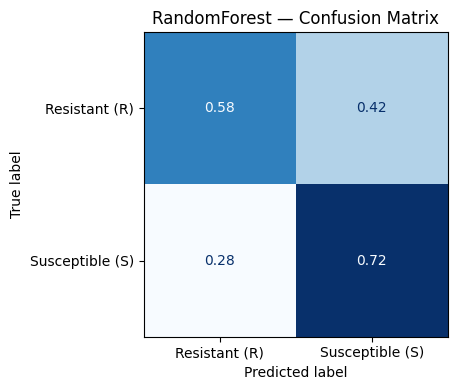

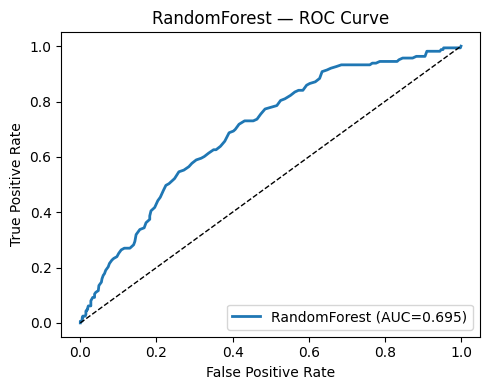

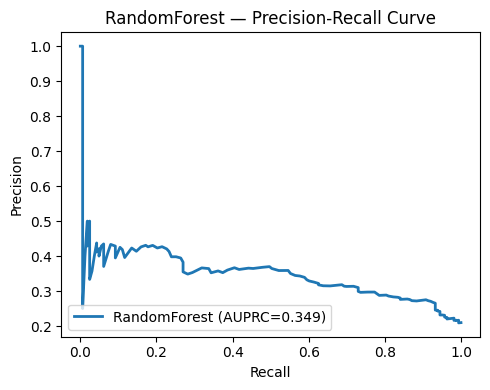

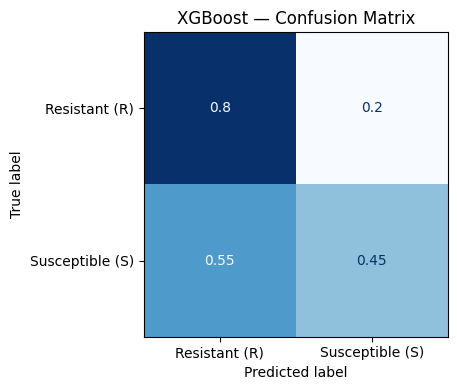

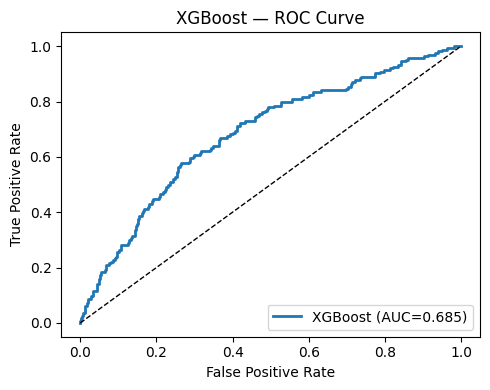

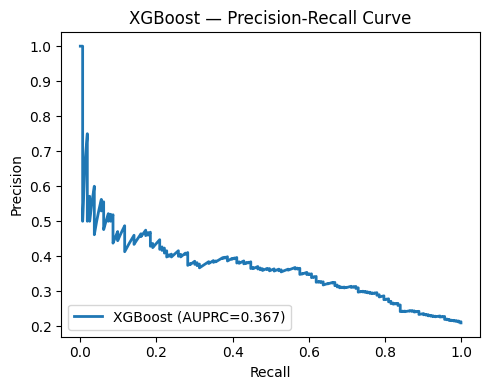

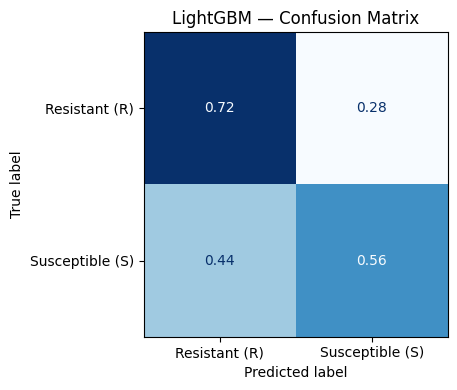

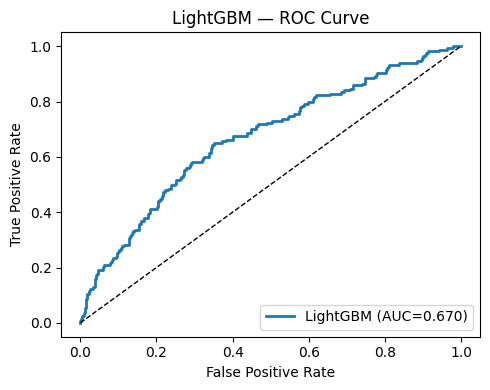

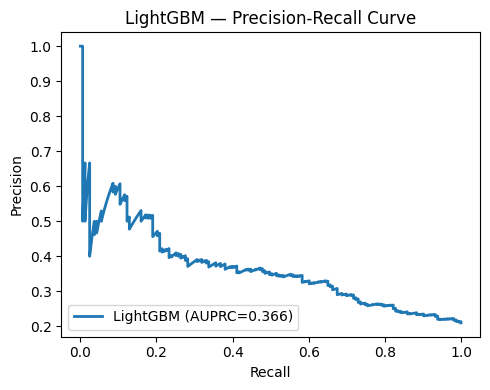

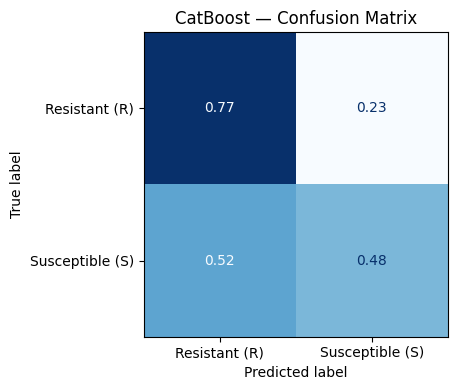

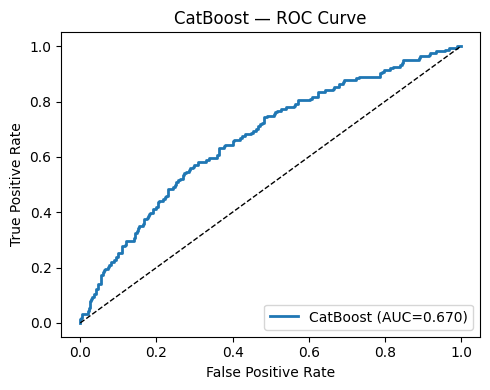

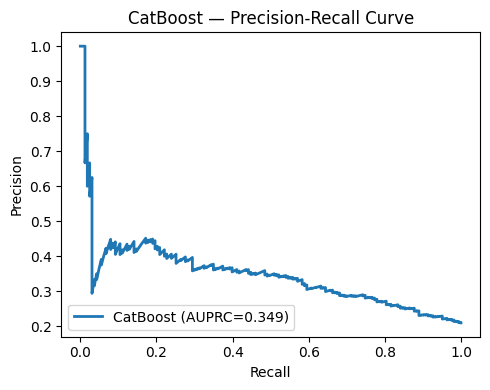

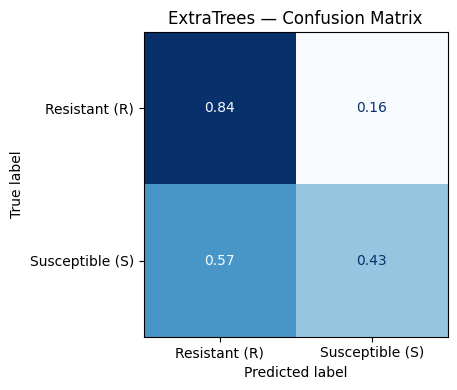

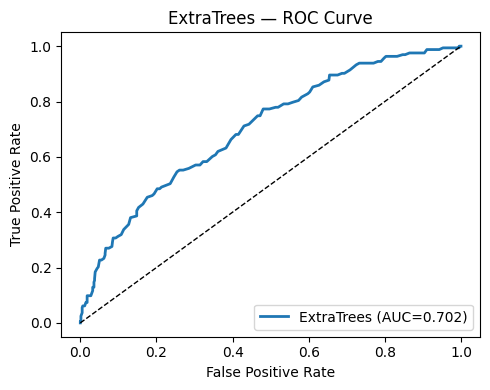

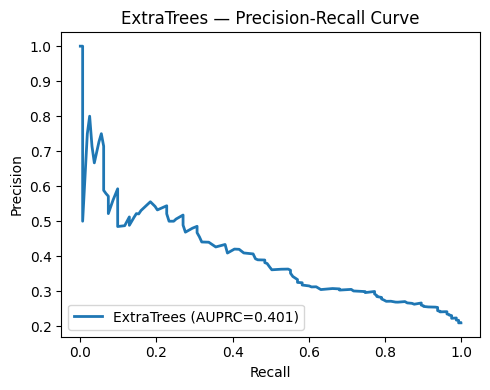

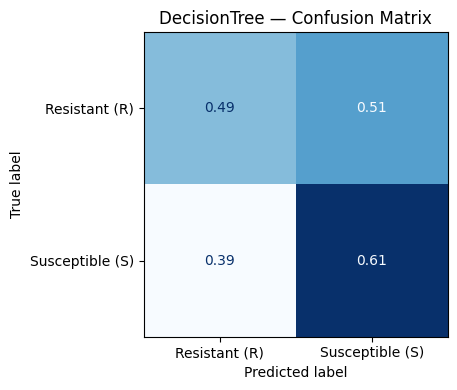

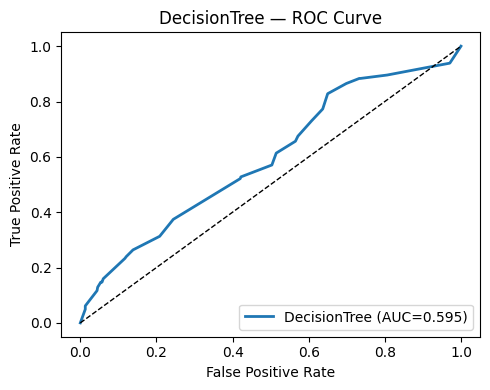

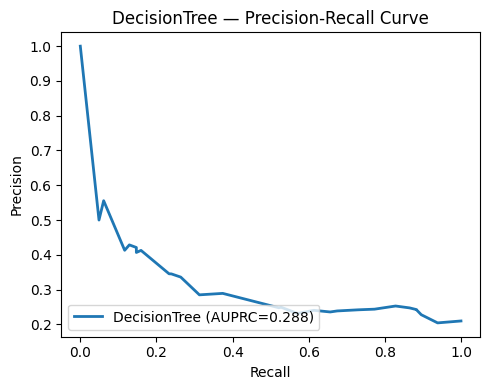

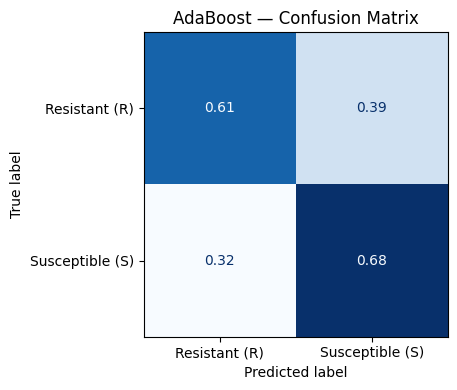

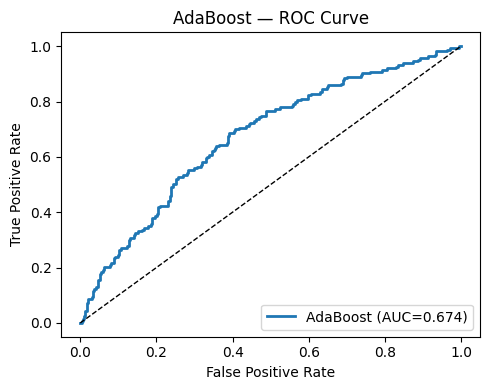

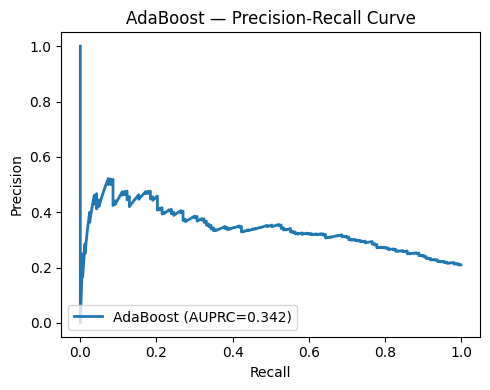

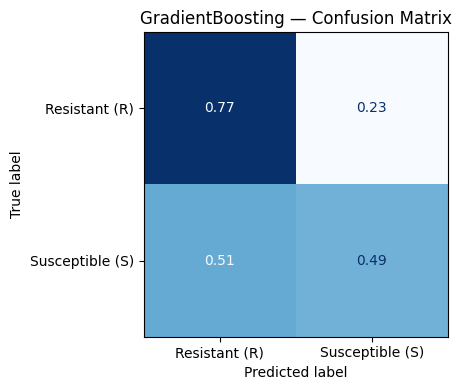

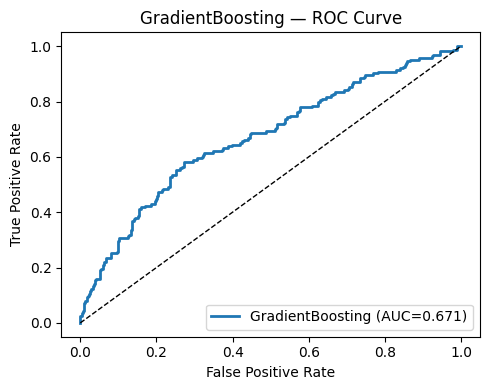

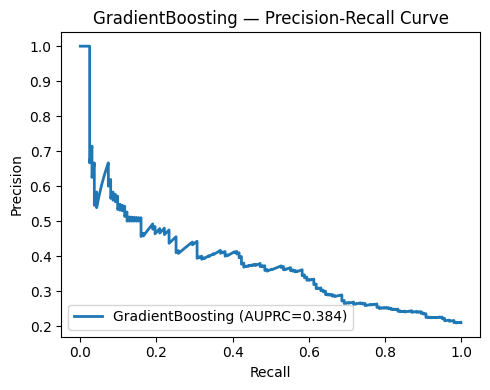

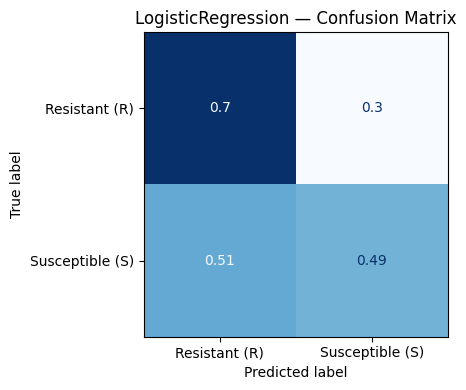

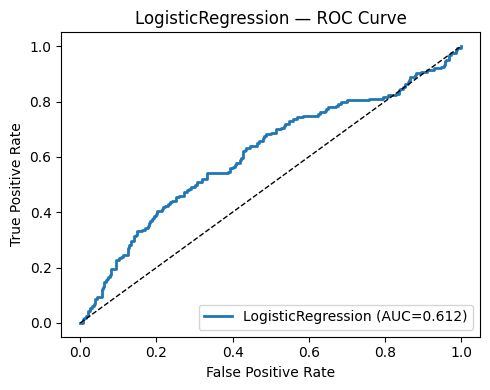

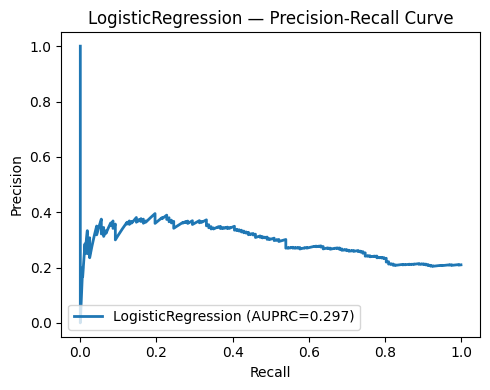

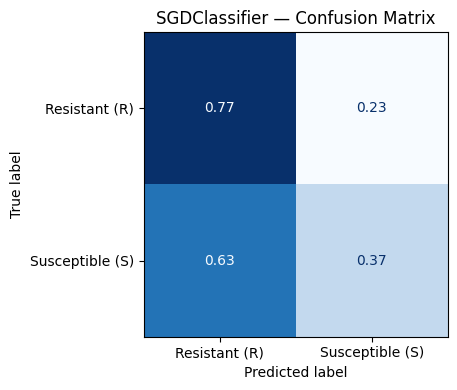

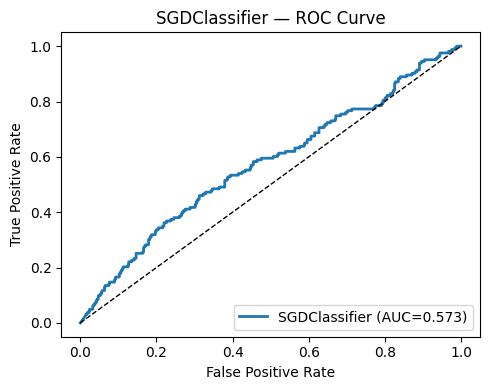

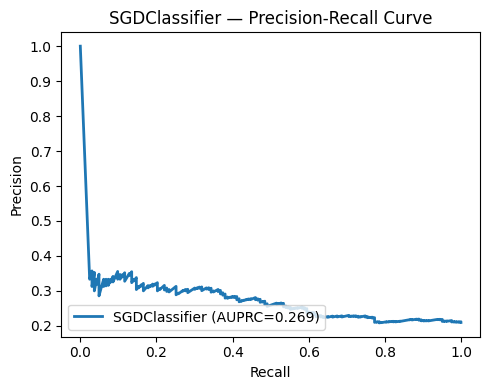

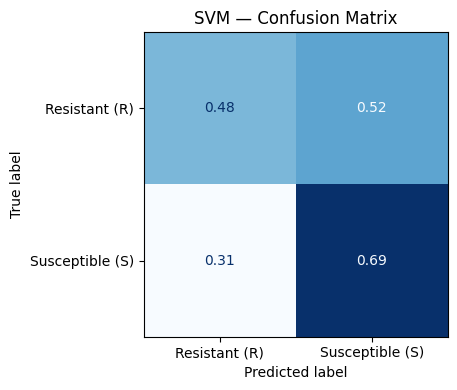

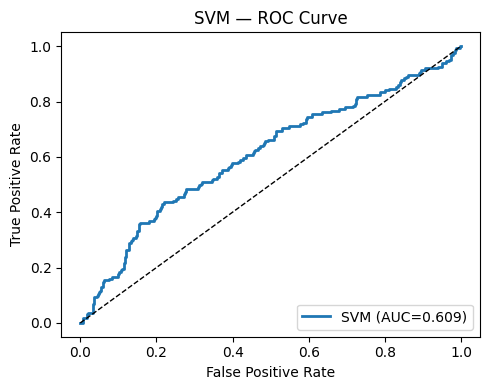

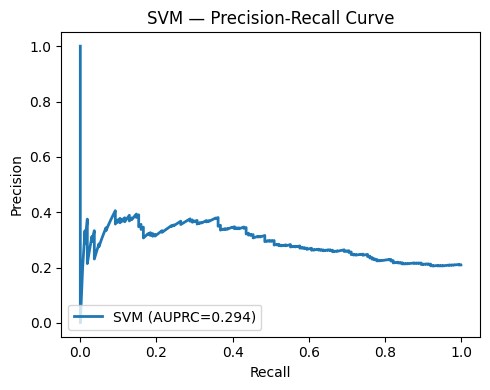

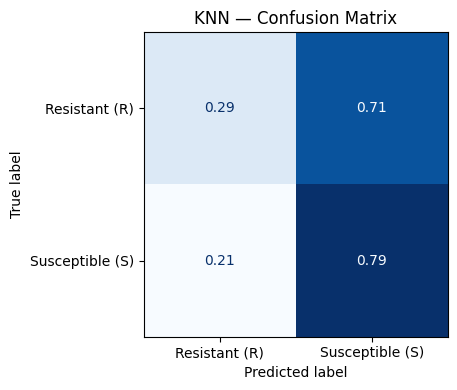

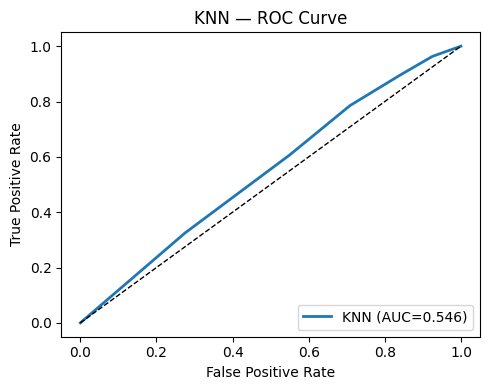

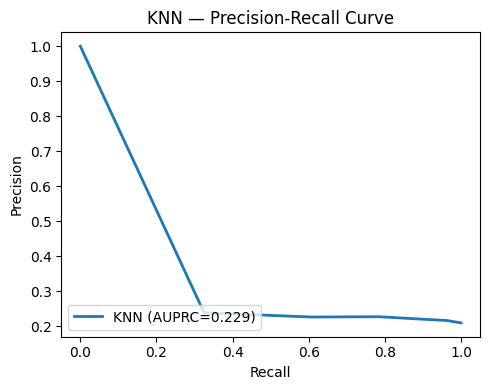

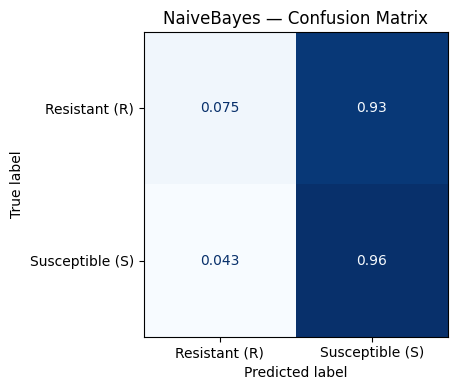

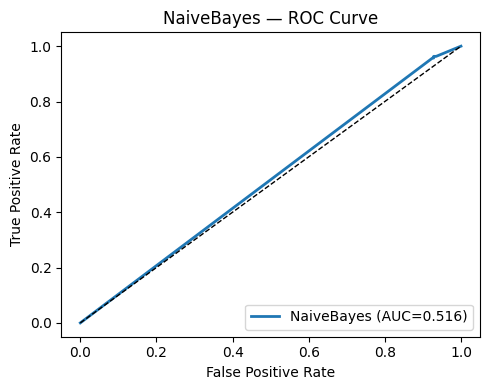

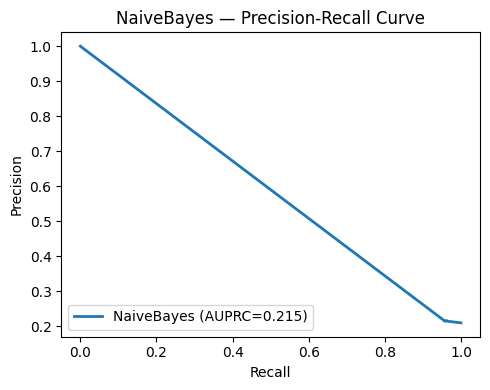

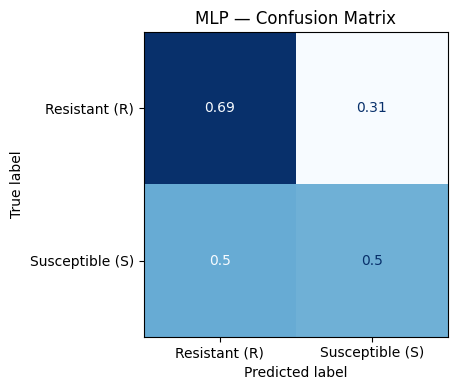

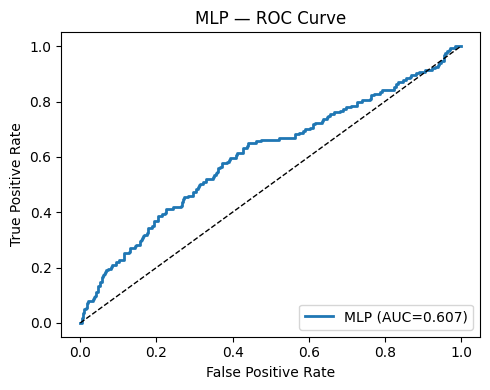

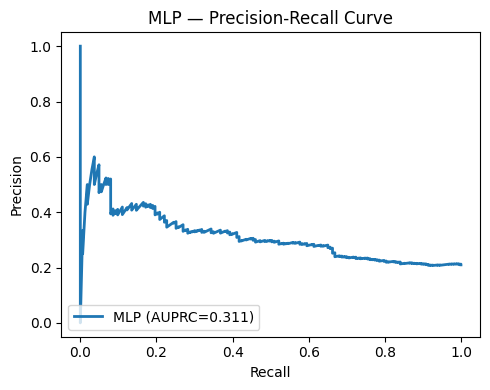

In [20]:
results = {}
model_thresholds = {}

for name, pipe in pipes.items():
    pipe.fit(X_train, y_train)
    metrics, cm, fig_cm, fig_roc, fig_pr, best_thresh = mm.evaluate_pipeline(
        pipe,
        X_test,
        y_test,
        model_name=name,
        threshold="optimize",
        optimize_metric="f1",
        X_val=X_val,
        y_val=y_val,
    )
    results[name] = metrics
    model_thresholds[name] = best_thresh

    mm.check_overfitting(
        pipe,
        X_train,
        y_train,
        X_val,
        y_val,
        model_name=name,
        threshold=best_thresh,
    )


## Tabular metrics (`evaluate_pipeline` uses AUROC / AUPRC keys)


In [15]:
summary = pd.DataFrame(results).T
summary


,Accuracy,Precision (PPV),Recall (Sensitivity),Specificity,NPV,F1,AUROC,AUPRC
RandomForest,0.742664,0.400844,0.524862,0.798582,0.867488,0.454545,0.742710,0.453204
XGBoost,0.778781,0.454545,0.414365,0.872340,0.852982,0.433526,0.739415,0.431104
LightGBM,0.748307,0.417969,0.591160,0.788652,0.882540,0.489703,0.744477,0.454912
CatBoost,0.711061,0.380952,0.662983,0.723404,0.893170,0.483871,0.748411,0.440090
ExtraTrees,0.741535,0.400826,0.535912,0.794326,0.869565,0.458629,0.748709,0.469882
DecisionTree,0.676072,0.341317,0.629834,0.687943,0.878623,0.442718,0.717476,0.373632
AdaBoost,0.782167,0.465909,0.453039,0.866667,0.860563,0.459384,0.747761,0.467552
GradientBoosting,0.776524,0.455959,0.486188,0.851064,0.865801,0.470588,0.732307,0.443261
LogisticRegression,0.778781,0.451613,0.386740,0.879433,0.848153,0.416667,0.732244,0.427503
SGDClassifier,0.646727,0.300000,0.546961,0.672340,0.852518,0.387476,0.671294,0.328028


## Bar chart: AUROC vs AUPRC


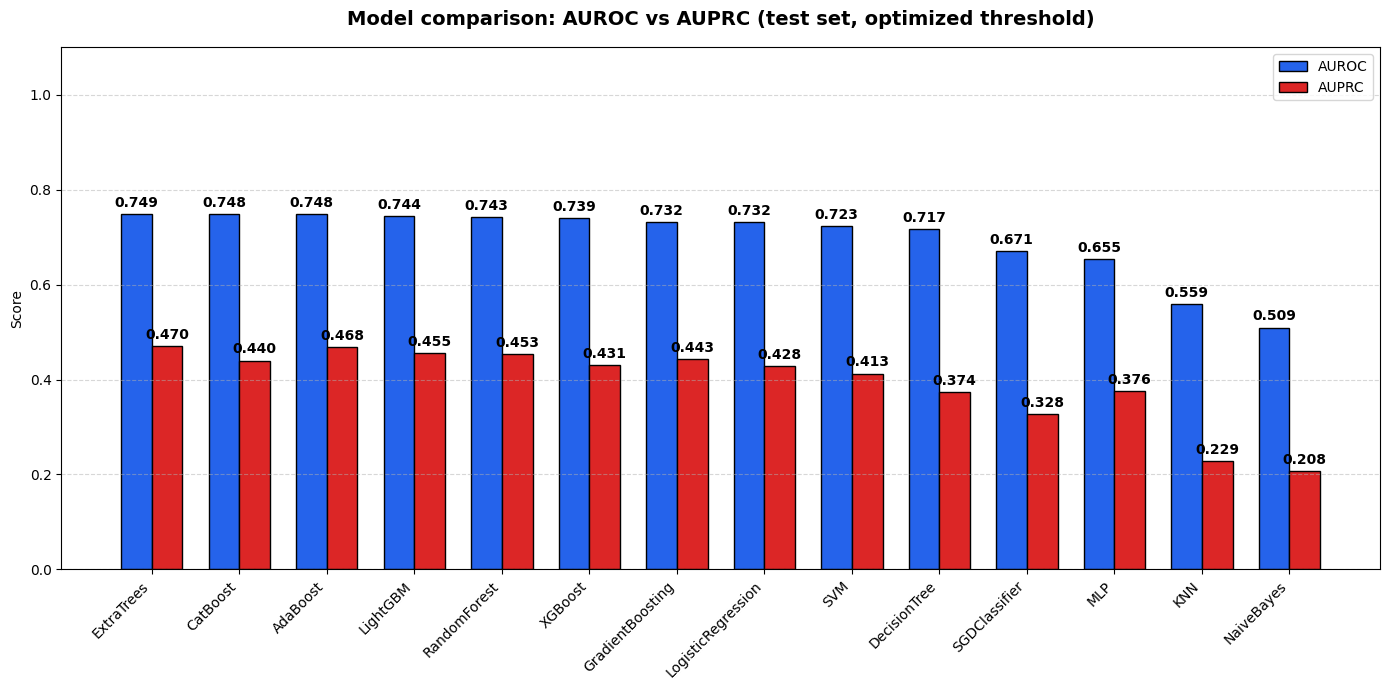

In [16]:
plot_rows = []
for name, metrics in results.items():
    plot_rows.append({
        "Model": name,
        "AUROC": metrics.get("AUROC"),
        "AUPRC": metrics.get("AUPRC"),
    })
df_plot = pd.DataFrame(plot_rows).dropna(subset=["AUROC", "AUPRC"])

df_plot = df_plot.sort_values(by="AUROC", ascending=False)
x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
r1 = ax.bar(x - width / 2, df_plot["AUROC"], width, label="AUROC", color="#2563EB", edgecolor="black")
r2 = ax.bar(x + width / 2, df_plot["AUPRC"], width, label="AUPRC", color="#DC2626", edgecolor="black")

ax.set_title("Model comparison: AUROC vs AUPRC (test set, optimized threshold)", fontsize=14, fontweight="bold", pad=16)
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Model"], rotation=45, ha="right")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.bar_label(r1, padding=3, fmt="%.3f", fontweight="bold")
ax.bar_label(r2, padding=3, fmt="%.3f", fontweight="bold")
plt.tight_layout()
plt.show()


## Optional: single-admission inspection

Uses `mm.inspect_single_patient` (fitted `pipe`, holdout row index = `hadm_id`).


In [ ]:
# Example: random holdout admission; set pid_value to a specific hadm_id to debug
mm.inspect_single_patient(
    df=feature_df,
    pipe=pipes["LightGBM"],
    X_test=X_test,
    y_test=y_test,
    pid_col="hadm_id",
    target_name="Inappropriate therapy",
    model_name="LightGBM",
    threshold=model_thresholds.get("LightGBM", 0.5),
    pid_value=None,
    class_rate_df=None,
)


## SHAP for tree ensembles

Runs only for models present in `pipes` and tree-like enough for `explain_pipeline`.



--- SHAP: RandomForest ---


100%|===================| 1765/1772 [03:15<00:00]        

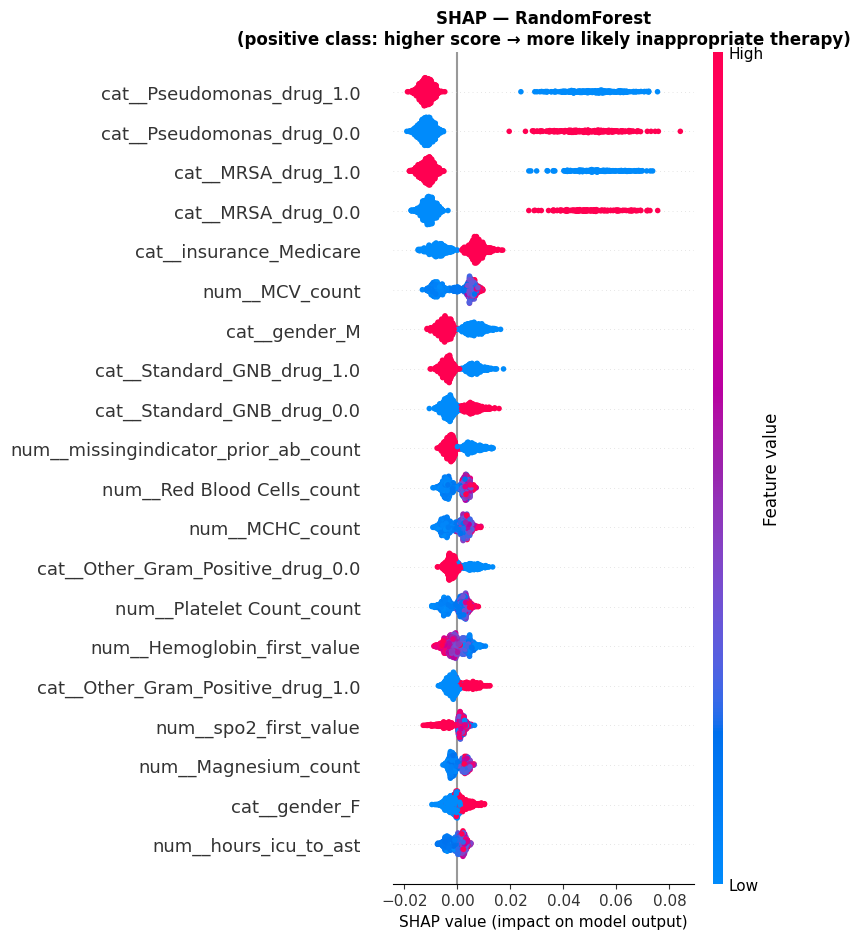

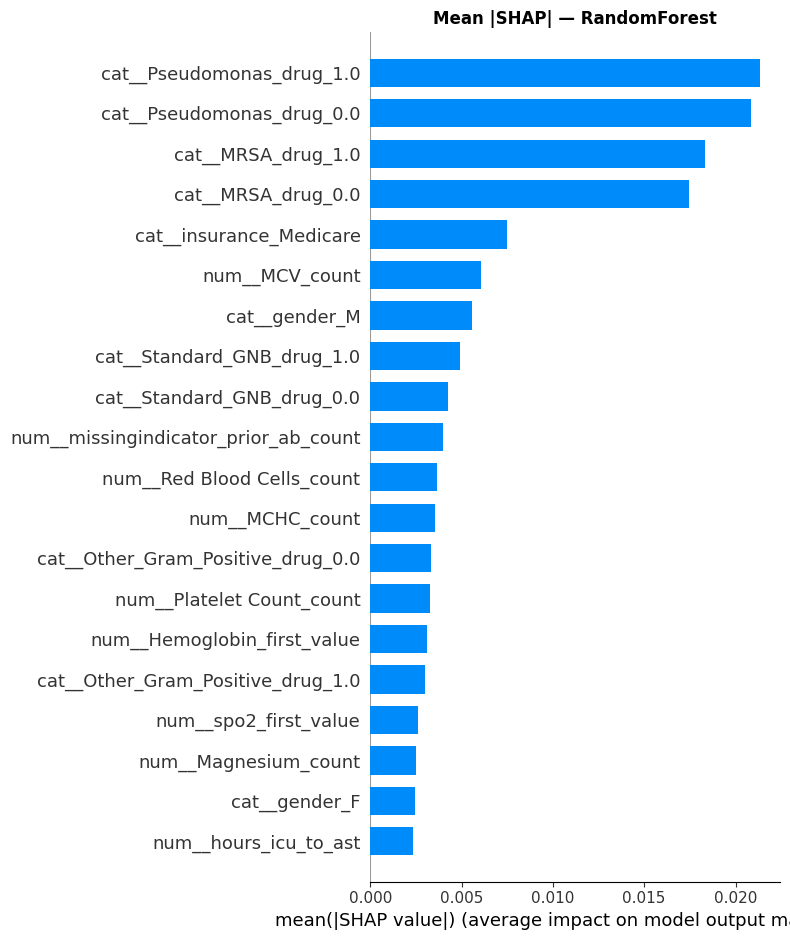


--- SHAP: XGBoost ---


 99%|===================| 874/886 [00:16<00:00]        

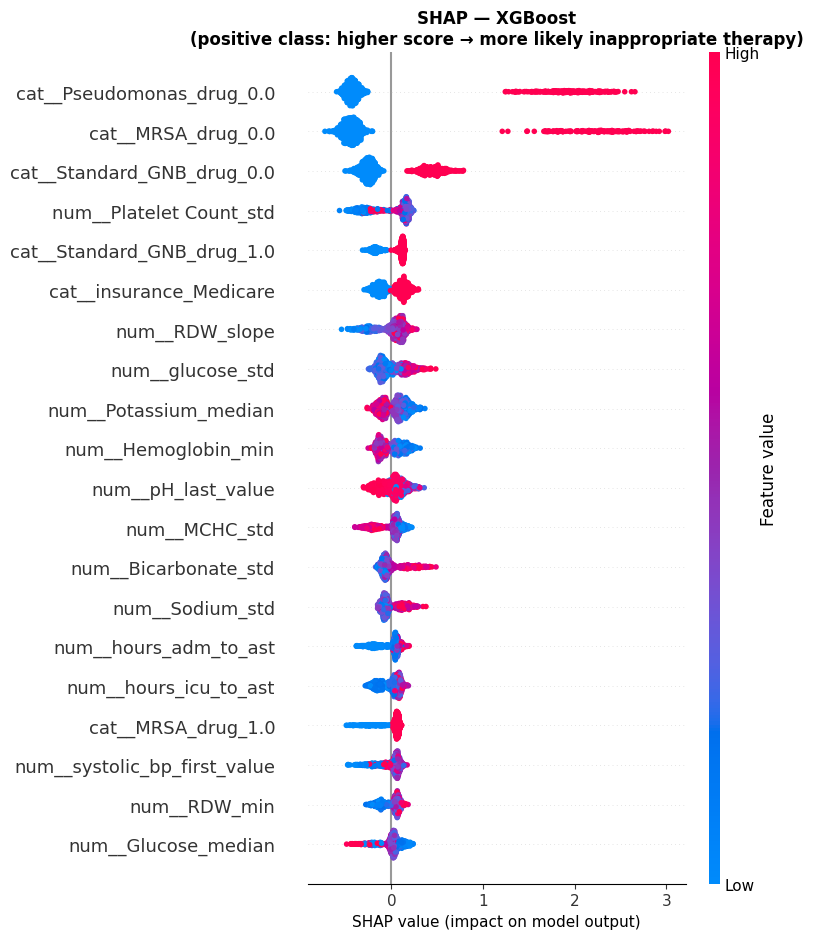

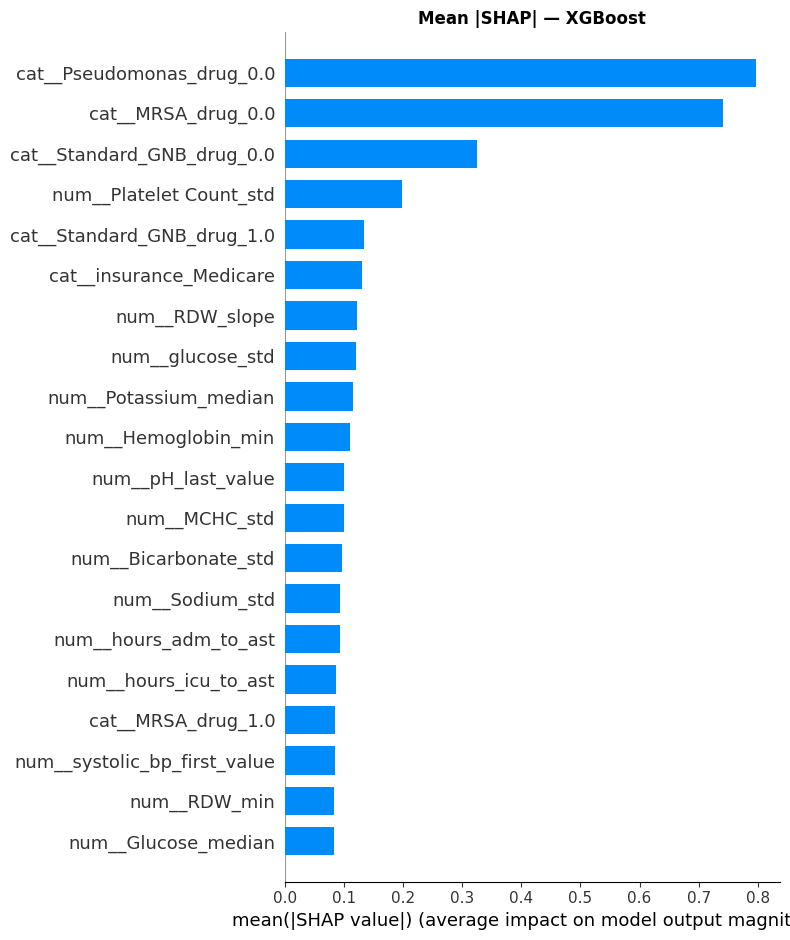


--- SHAP: LightGBM ---


 98%|===================| 872/886 [00:19<00:00]        

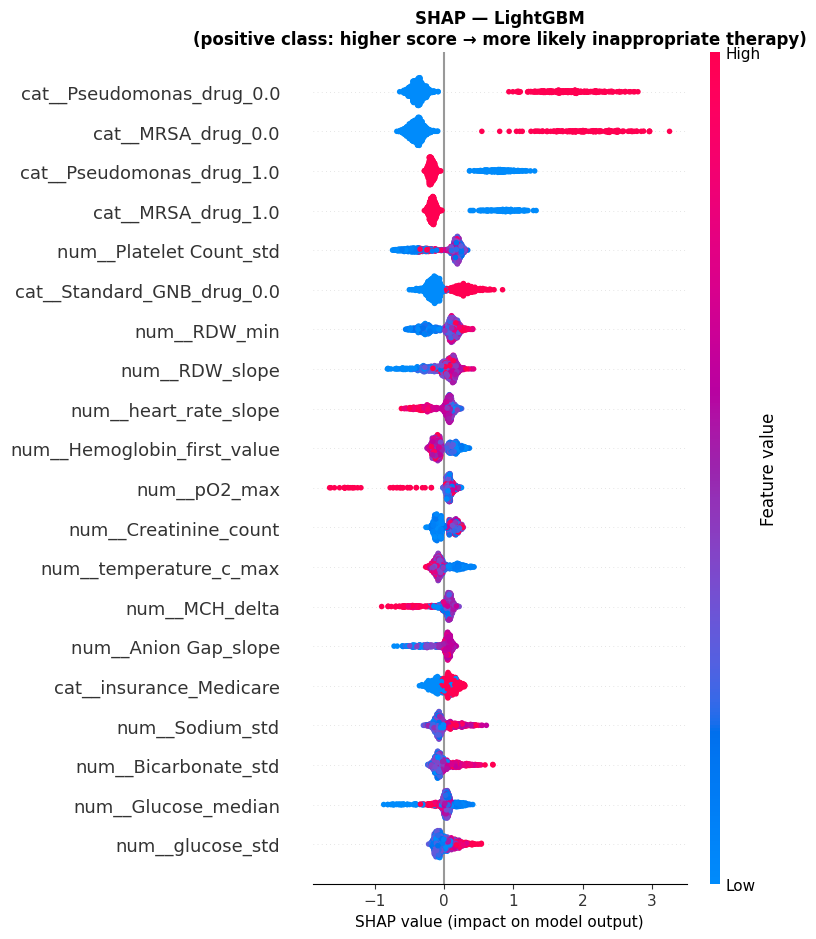

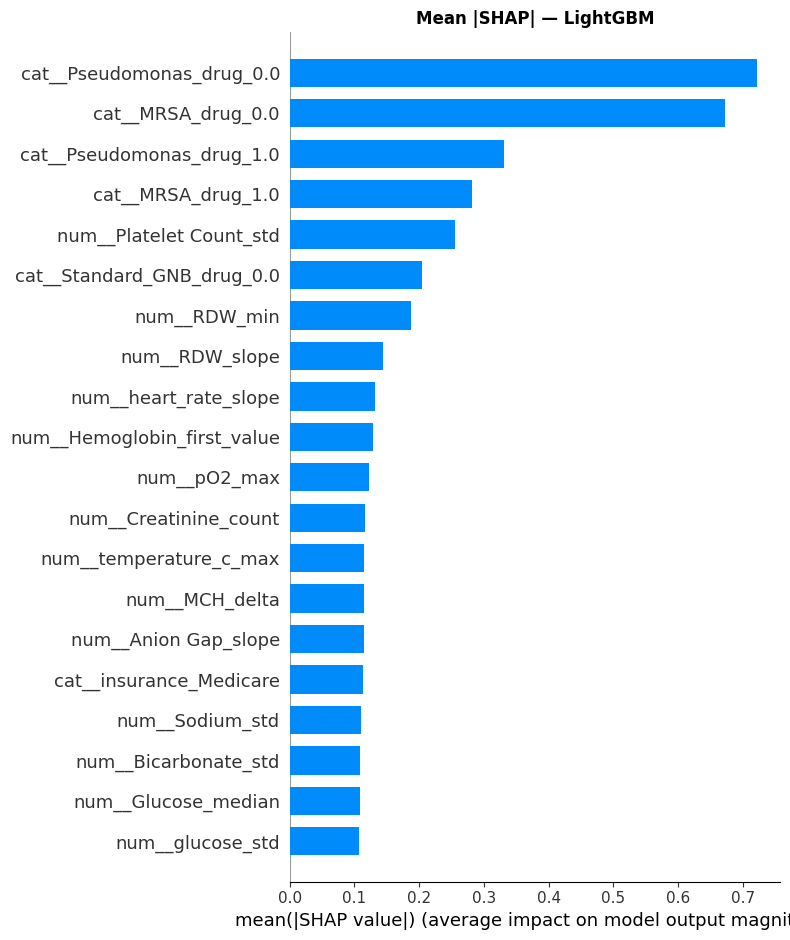


--- SHAP: CatBoost ---


 96%|=================== | 847/886 [00:13<00:00]       

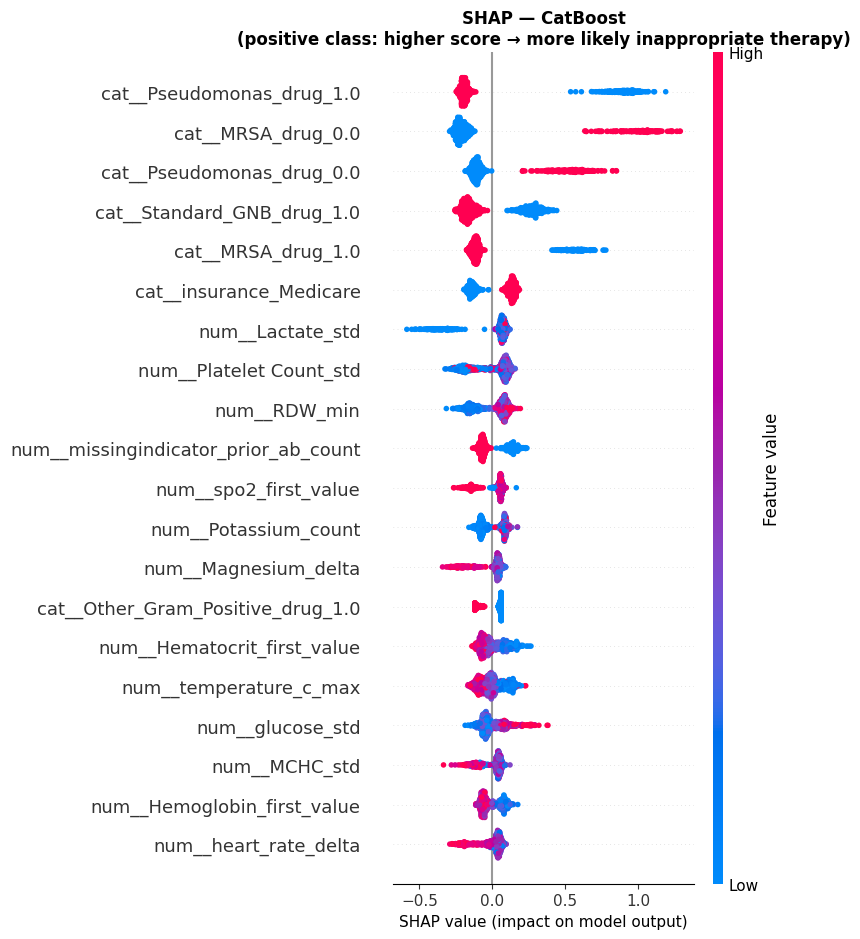

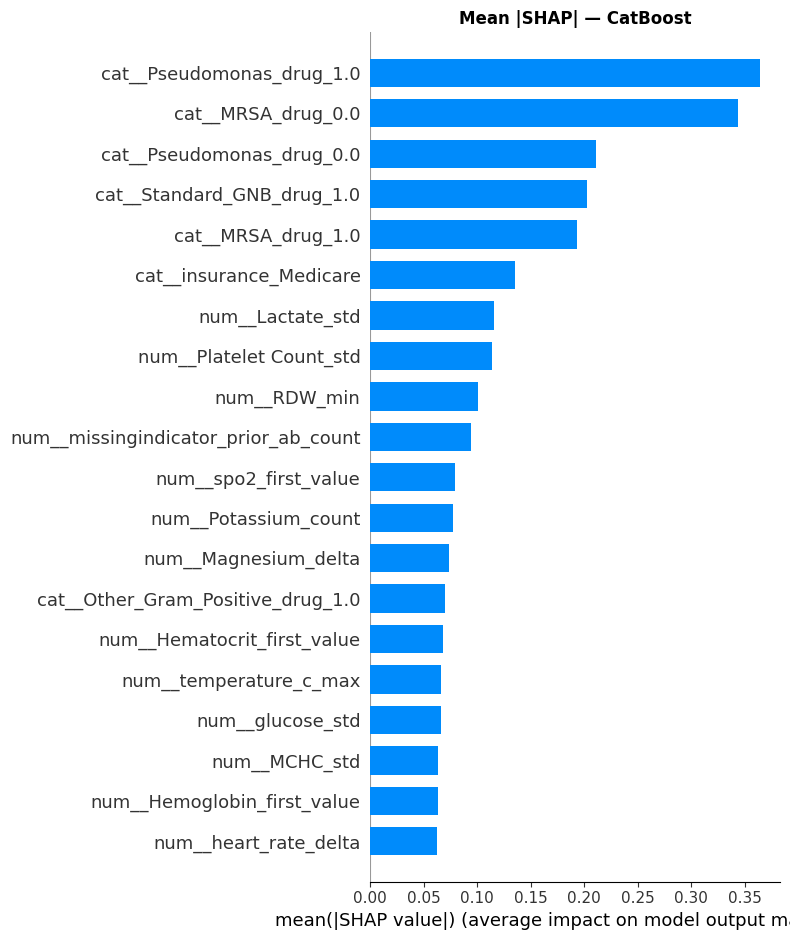

In [17]:
for name, pipe in pipes.items():
    if name not in ("RandomForest", "LightGBM", "XGBoost", "CatBoost"):
        continue
    print(f"\n--- SHAP: {name} ---")
    mm.explain_pipeline(pipe, X_test, model_name=name)


## SHAP for the model you report as primary

Set `FINAL_MODEL_NAME` to match your manuscript / best validation metric.


 94%|=================== | 753/800 [00:17<00:01]       

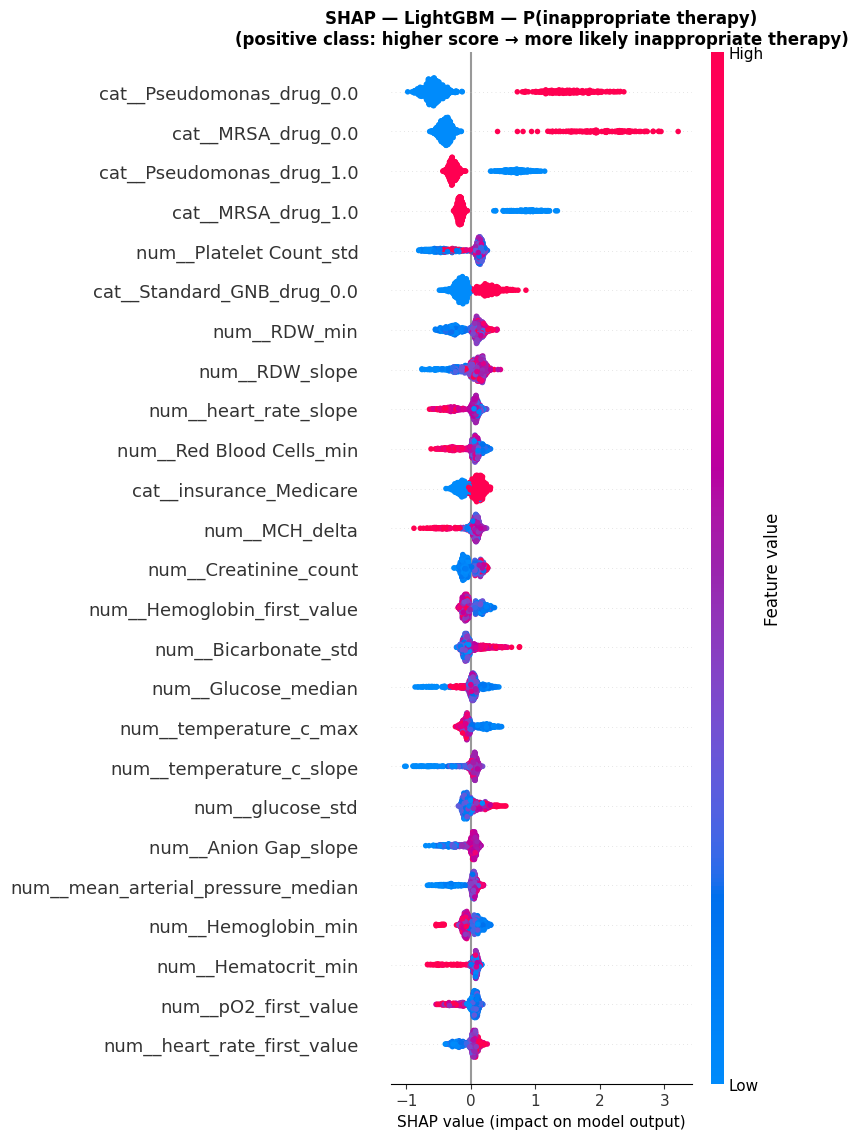

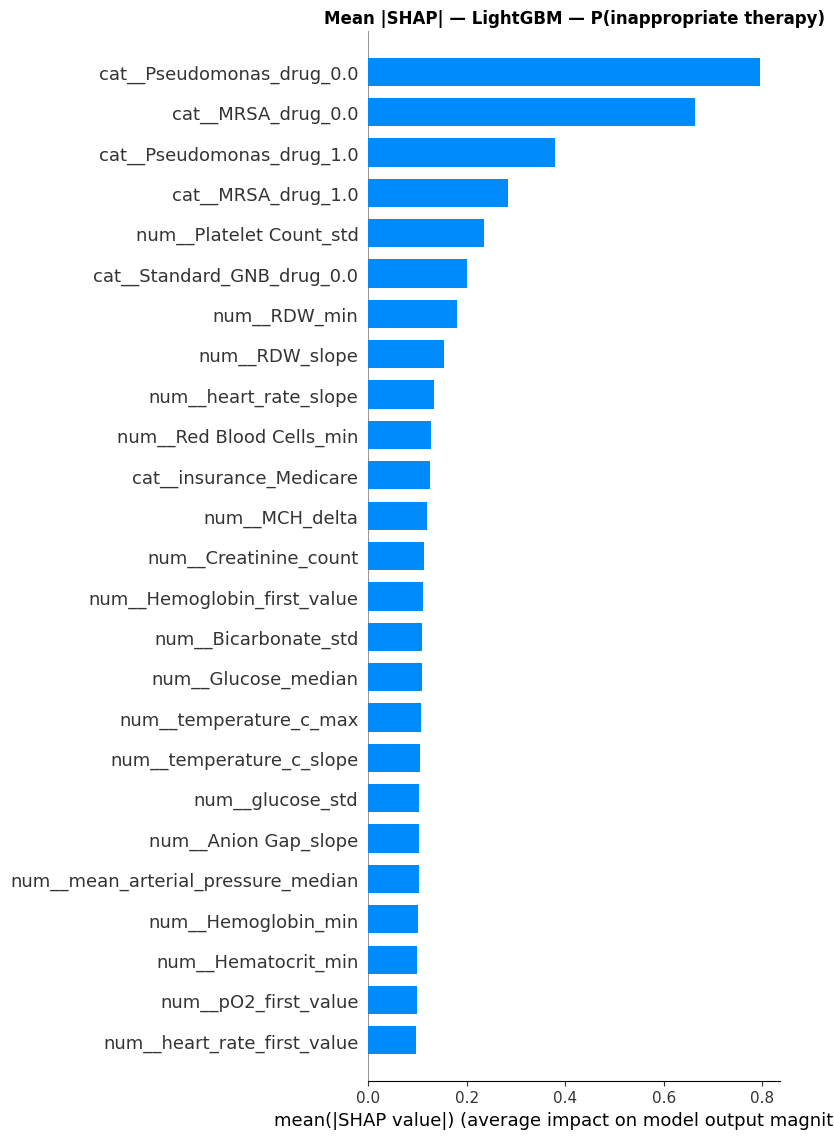

array([[-0.04862033, -0.01665924,  0.0113842 , ..., -0.01831013,
        -0.00090628,  0.00030267],
       [-0.03750672, -0.04362015,  0.00074641, ...,  0.06364497,
        -0.02130677,  0.00027178],
       [-0.00152725,  0.01438139,  0.00098004, ..., -0.01288011,
        -0.0096759 ,  0.00041076],
       ...,
       [-0.00460654,  0.01015081, -0.00073361, ..., -0.02407969,
        -0.00133949, -0.00274406],
       [ 0.11338761,  0.0169129 , -0.03695161, ..., -0.00561631,
        -0.00050545, -0.00433769],
       [-0.00654364, -0.00315065, -0.00579624, ..., -0.01553834,
         0.00143683, -0.00300503]], shape=(800, 848))

In [18]:
FINAL_MODEL_NAME = "LightGBM"

final_pipe = pipes[FINAL_MODEL_NAME]

mm.explain_pipeline(
    final_pipe,
    X_test,
    model_name=f"{FINAL_MODEL_NAME} — P(inappropriate therapy)",
    max_display=25,
    background_size=min(300, len(X_train)),
    max_eval_samples=min(800, len(X_test)),
    random_state=42,
    check_additivity=False,
    show_bar=True,
)

# Optional single-row waterfall (uncomment):
# pid = X_test.index[0]
# mm.explain_single_binary_prediction(
#     final_pipe, X_test.loc[[pid]], X_train,
#     model_name=FINAL_MODEL_NAME, max_display=15,
# )
